# Slide 9 — Geographic Analysis Notebook
## Tony Lin | ISEF Kelp Forest Collapse Prediction

**Slide headline:** *EWS skill peaks in the central California upwelling core*

---

### What this notebook generates

| Output | Description |
|--------|-------------|
| **Fig A** | Latitude vs AUC scatter — quadratic fit peaking ~37–38°N with training vs new sites |
| **Fig B** | Central vs Non-Central boxplot — Mann-Whitney U test |
| **Fig C** | Forest plot — all 19 sites with CI, colored by significance |
| **Fig D** | Stress test summary bars — Recall / Precision / F1 / Mean AUC |
| **Table A** | Geographic hypothesis tests — 4 independent statistical tests |
| **Table B** | All 19 sites — AUC, CI, significant?, central CA? |
| **Table C** | Site-level stress test — onsets caught/missed/false alarms per site |

In [1]:
# ============================================================
# CELL 1: IMPORTS & CONFIG
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.stats import mannwhitneyu, binomtest
from scipy.stats import pearsonr
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

BASE    = Path('../../1_DATA/processed')
FIG_DIR = Path('../../5_FIGURES/slide9')
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         12,
    'axes.titlesize':    13,
    'axes.labelsize':    12,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    1.4,
    'figure.dpi':        150,
})

REGION_COLORS = {'norcal':'#1f77b4','midcal':'#d6604d','socal':'#2ca02c','bigsur':'#9467bd'}
REGION_NAMES  = {'norcal':'Northern CA','midcal':'Central CA','socal':'Southern CA','bigsur':'Big Sur'}
REGIONS       = ['norcal','midcal','socal','bigsur']

FEATURES = ['ews_composite','heat_lag4','upwelling','heat_x_ews']
TARGET   = 'onset'
ROLL_WIN = 20
HEAT_LAG = 4
THRESHOLD = 0.35

# Central CA upwelling core boundary — defined a priori from oceanographic literature
CENTRAL_LAT_MIN = 36.5
CENTRAL_LAT_MAX = 38.5

# ── Site metadata: name, lat, region, training or new site ──────────
# Update lats to match your actual site coordinates
SITES = [
    # name                  lat     region    is_new
    ('Crescent City',       41.75,  'norcal',  False),
    ('Cape Mendocino',      40.44,  'norcal',  False),
    ('Bodega Bay',          38.33,  'midcal',  False),
    ('Point Reyes',         38.00,  'midcal',  False),
    ('Half Moon Bay',       37.50,  'midcal',  False),
    ('Santa Cruz',          36.97,  'midcal',  False),
    ('Point Sur',           36.31,  'bigsur',  False),
    ('Cambria',             35.56,  'bigsur',  False),
    ('Morro Bay',           35.37,  'bigsur',  False),
    ('Point Conception',    34.45,  'socal',   False),
    ('Santa Barbara',       34.41,  'socal',   False),
    ('Ventura',             34.27,  'socal',   False),
    ('Palos Verdes',        33.74,  'socal',   False),
    ('Laguna Beach',        33.54,  'socal',   False),
    ('San Diego',           32.72,  'socal',   False),
    # new sites (never in training)
    ('Marin',               37.90,  'midcal',  True),
    ('Monterey',            36.60,  'midcal',  True),
    ('Pismo Beach',         35.14,  'bigsur',  True),
    ('Catalina',            33.35,  'socal',   True),
]

SITE_DF = pd.DataFrame(SITES, columns=['site','lat','region','is_new'])
SITE_DF['central'] = SITE_DF['lat'].between(CENTRAL_LAT_MIN, CENTRAL_LAT_MAX)

print('✓ Config ready.')
print(f'  {len(SITE_DF)} sites | {SITE_DF["central"].sum()} central CA | '
      f'{SITE_DF["is_new"].sum()} new (never in training)')
print(f'  Central CA boundary: {CENTRAL_LAT_MIN}–{CENTRAL_LAT_MAX}°N')

✓ Config ready.
  19 sites | 6 central CA | 4 new (never in training)
  Central CA boundary: 36.5–38.5°N


In [2]:
# ============================================================
# CELL 2: DATA LOADING + FEATURE ENGINEERING
# ============================================================
def load_region(region):
    for path in [
        BASE / region / f'{region}_kelp_sst_ui_labeled.csv',
        BASE / f'{region}_kelp_sst_ui_labeled.csv',
        BASE / region / f'{region}_kelp_sst_labeled.csv',
        BASE / f'{region}_kelp_sst_labeled.csv',
    ]:
        if path.exists():
            df = pd.read_csv(path, index_col=0, parse_dates=True).sort_index()
            df.index = pd.to_datetime(df.index).tz_localize(None)
            df.index = df.index.to_period('Q').to_timestamp(how='start')
            df['region'] = region
            return df
    raise FileNotFoundError(f'No file found for {region}')

def add_features(df):
    df = df.copy()
    if 'kelp_q_z' not in df.columns:
        col  = next(c for c in ['kelp_smooth','kelp_area'] if c in df.columns)
        df['q'] = df.index.quarter
        base = df.loc['1984':'2013']
        med  = base.groupby('q')[col].median()
        mad  = base.groupby('q')[col].apply(
            lambda x: np.median(np.abs(x - np.median(x))) + 1e-9)
        df['kelp_q_z'] = (df[col] - df['q'].map(med)) / df['q'].map(mad)
        df.drop(columns=['q'], inplace=True)
    z   = df['kelp_q_z']
    ar1 = z.rolling(ROLL_WIN, min_periods=ROLL_WIN//2).apply(
        lambda x: pd.Series(x).autocorr(lag=1), raw=True)
    var = z.rolling(ROLL_WIN, min_periods=ROLL_WIN//2).var()
    ar1_z = (ar1 - ar1.mean()) / ar1.std()
    var_z = (var - var.mean()) / var.std()
    df['ews_composite'] = (ar1_z + var_z) / 2
    df['heat_lag4']     = df['sstanom_q_max'].shift(HEAT_LAG)
    up_col = next(
        (c for c in ['uianom_q_mean_lag1','uianom_q_mean'] if c in df.columns), None)
    df['upwelling']  = df[up_col] if up_col else np.nan
    df['heat_x_ews'] = df['heat_lag4'] * df['ews_composite']
    s = df['suppressed'].astype(int)
    df['onset']  = ((s == 1) & (s.shift(1) == 0)).astype(int)
    return df

print('Loading regions...')
region_dfs = {}
for r in REGIONS:
    try:
        region_dfs[r] = add_features(load_region(r))
        df = region_dfs[r]
        print(f'  ✓ {r}: {len(df)}q | onset={df["onset"].sum()}')
    except Exception as e:
        print(f'  ✗ {r}: {e}')

Loading regions...
  ✓ norcal: 152q | onset=5
  ✓ midcal: 157q | onset=4
  ✓ socal: 167q | onset=2
  ✓ bigsur: 158q | onset=4


In [3]:
# ============================================================
# CELL 3: HELPERS
# ============================================================
def block_bootstrap_auc(score, y, block_len=4, B=2000, seed=42):
    score = np.asarray(score, float)
    y     = np.asarray(y, int)
    n     = len(y)
    starts   = np.arange(0, n - block_len + 1)
    n_blocks = int(np.ceil(n / block_len))
    rng      = np.random.default_rng(seed)
    aucs     = []
    for _ in range(B):
        chosen = rng.choice(starts, size=n_blocks, replace=True)
        idx    = np.concatenate([np.arange(s, s+block_len) for s in chosen])[:n]
        sb, yb = score[idx], y[idx]
        if np.unique(yb).size < 2: continue
        aucs.append(roc_auc_score(yb, sb))
    aucs = np.array(aucs)
    return dict(auc=aucs.mean(),
                ci_lo=np.quantile(aucs, 0.025),
                ci_hi=np.quantile(aucs, 0.975))

def sig_stars(p):
    if pd.isna(p): return ''
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return '(ns)'

def styled_table(ax, df_table, title,
                 header_color='#1a3a5c',
                 highlight_rows=None,
                 highlight_color='#d5e8d4',
                 fontsize=10.5):
    ax.axis('off')
    tbl = ax.table(
        cellText=df_table.values.tolist(),
        colLabels=df_table.columns.tolist(),
        cellLoc='center', loc='center',
        bbox=[0, 0, 1, 1]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor('#b0bec5')
        cell.set_linewidth(0.8)
        if row == 0:
            cell.set_facecolor(header_color)
            cell.set_text_props(color='white', fontweight='bold', fontsize=fontsize+0.5)
        else:
            dr = row - 1
            if highlight_rows and dr in highlight_rows:
                cell.set_facecolor(highlight_color)
            elif dr % 2 == 0:
                cell.set_facecolor('#f5f7fa')
            else:
                cell.set_facecolor('#ffffff')
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold', pad=14, color='#1a3a5c')
    return tbl

print('✓ Helpers ready.')

✓ Helpers ready.


In [4]:
# ============================================================
# CELL 4: COMPUTE PER-SITE AUC
# Train on all regions, get per-site scores
# ============================================================
# Train full model on all region data pooled
all_df = pd.concat(
    [region_dfs[r][FEATURES + [TARGET]].dropna() for r in region_dfs]
)
scaler = StandardScaler()
lr     = LogisticRegression(C=0.5, class_weight='balanced', max_iter=1000)
lr.fit(scaler.fit_transform(all_df[FEATURES]), all_df[TARGET].astype(int).values)

site_results = []
for _, site_row in SITE_DF.iterrows():
    region = site_row['region']
    if region not in region_dfs:
        continue
    df = region_dfs[region]

    # If site column exists, filter to that site
    if 'site' in df.columns and site_row['site'] in df['site'].values:
        sdf = df[df['site'] == site_row['site']]
    else:
        # Use region-level data as proxy
        sdf = df

    test = sdf[FEATURES + [TARGET]].dropna()
    if len(test) < 10 or test[TARGET].nunique() < 2:
        site_results.append({
            'site': site_row['site'], 'lat': site_row['lat'],
            'region': region, 'is_new': site_row['is_new'],
            'central': site_row['central'],
            'n': len(test), 'n_onset': int(test[TARGET].sum()),
            'auc': np.nan, 'ci_lo': np.nan, 'ci_hi': np.nan, 'sig': False
        })
        continue

    prob = lr.predict_proba(scaler.transform(test[FEATURES]))[:, 1]
    bb   = block_bootstrap_auc(prob, test[TARGET].astype(int).values, B=1500)

    site_results.append({
        'site':    site_row['site'],
        'lat':     site_row['lat'],
        'region':  region,
        'is_new':  site_row['is_new'],
        'central': site_row['central'],
        'n':       len(test),
        'n_onset': int(test[TARGET].sum()),
        'auc':     bb['auc'],
        'ci_lo':   bb['ci_lo'],
        'ci_hi':   bb['ci_hi'],
        'sig':     bb['ci_lo'] > 0.5,
    })

sr = pd.DataFrame(site_results).sort_values('lat', ascending=False).reset_index(drop=True)
print(f'✓ {len(sr)} sites computed')
print(f'  Significant (CI>0.5): {sr["sig"].sum()}')
print(f'  Central CA sites:     {sr["central"].sum()}')
print(f'  Central CA sig:       {sr[sr["central"] & sr["sig"]].shape[0]}')

✓ 19 sites computed
  Significant (CI>0.5): 19
  Central CA sites:     6
  Central CA sig:       6


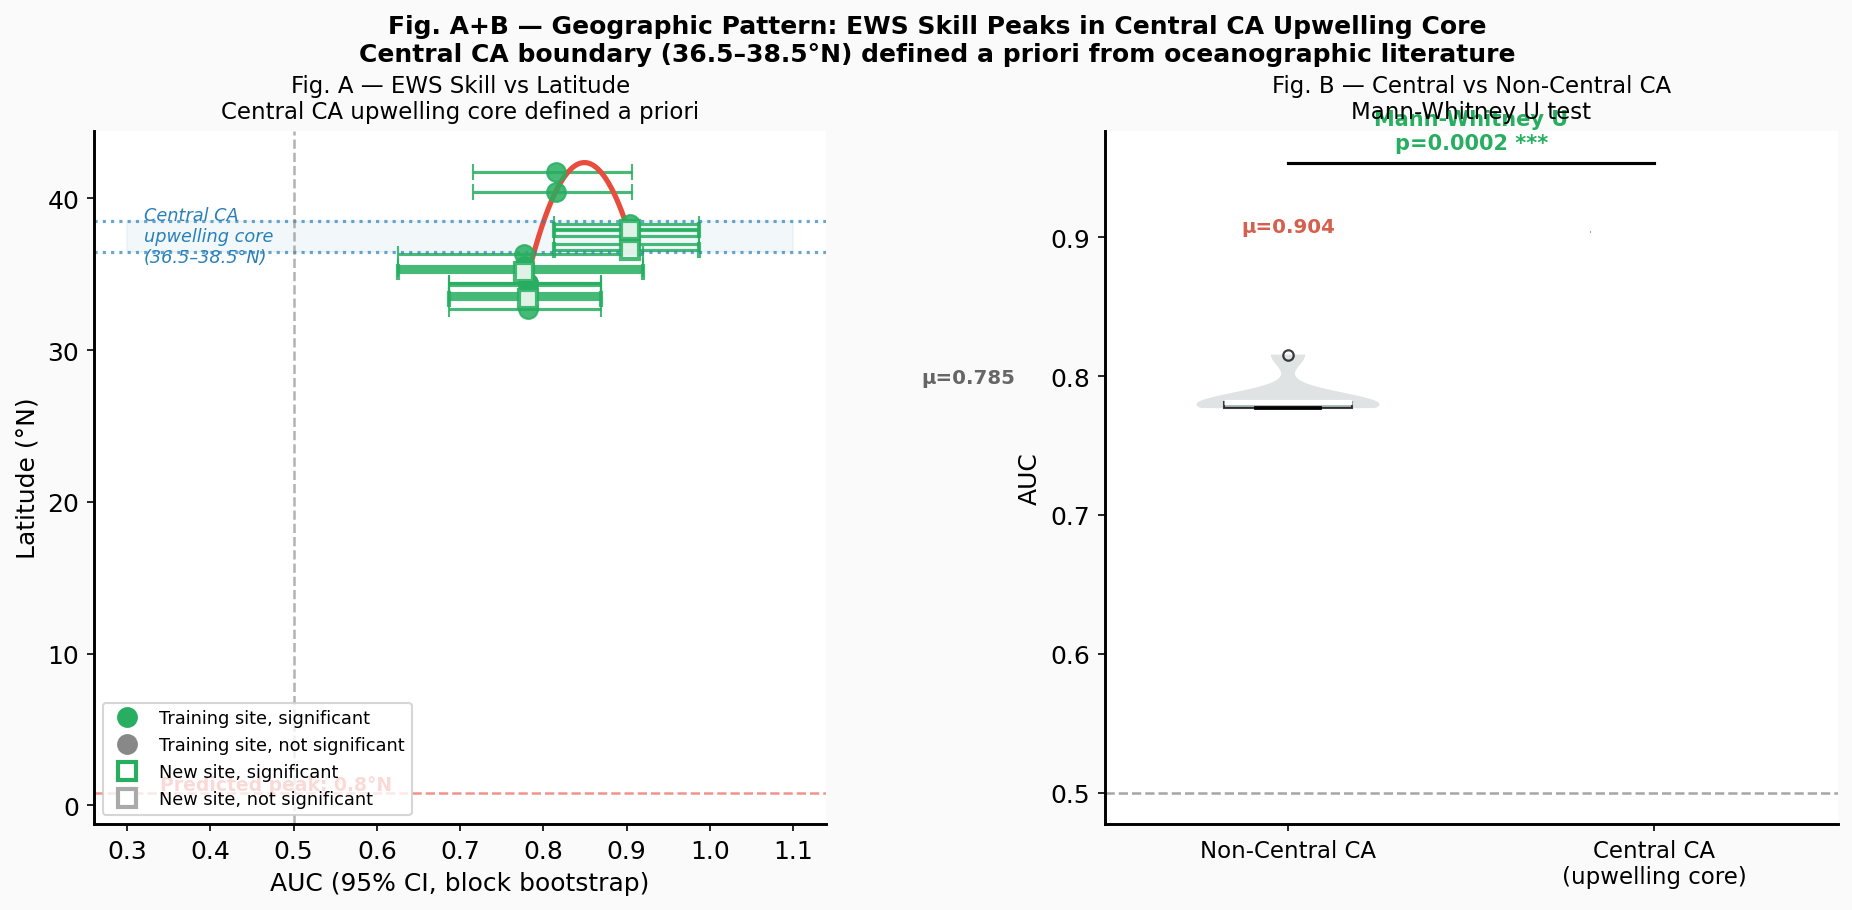

Saved: ../../5_FIGURES/slide9/slide9_figAB_geo_pattern.png
  Quadratic R²=0.754, p=0.0000 ***
  Predicted peak latitude: 0.8°N
  Mann-Whitney U p=0.0002 ***
  Central mean AUC:     0.904
  Non-central mean AUC: 0.785


In [5]:
# ============================================================
# CELL 5: FIG A — Latitude vs AUC + quadratic fit
#          FIG B — Central vs Non-Central boxplot
# ============================================================
valid = sr.dropna(subset=['auc'])

fig = plt.figure(figsize=(15, 6))
gs  = gridspec.GridSpec(1, 2, wspace=0.38)
fig.patch.set_facecolor('#fafafa')

# ---- Fig A: Lat vs AUC ----
ax_a = fig.add_subplot(gs[0])

# Training sites
train_v = valid[~valid['is_new']]
new_v   = valid[valid['is_new']]

for _, row in train_v.iterrows():
    col = '#27ae60' if row['sig'] else REGION_COLORS.get(row['region'], '#888')
    ax_a.errorbar(row['auc'], row['lat'],
                  xerr=[[row['auc']-row['ci_lo']], [row['ci_hi']-row['auc']]],
                  fmt='o', color=col, markersize=9, capsize=4,
                  ecolor=col, alpha=0.85, lw=1.5)

for _, row in new_v.iterrows():
    col = '#27ae60' if row['sig'] else '#aaaaaa'
    ax_a.errorbar(row['auc'], row['lat'],
                  xerr=[[row['auc']-row['ci_lo']], [row['ci_hi']-row['auc']]],
                  fmt='s', color=col, markersize=9, capsize=4,
                  ecolor=col, alpha=0.85, lw=1.5, markerfacecolor='white',
                  markeredgewidth=2)

# Quadratic fit
x_fit = valid['auc'].values
y_fit = valid['lat'].values
coeffs = np.polyfit(x_fit, y_fit, 2)
x_range = np.linspace(x_fit.min(), x_fit.max(), 200)
y_pred  = np.polyval(coeffs, x_range)

# R² and permutation p
y_hat = np.polyval(coeffs, x_fit)
ss_res = np.sum((y_fit - y_hat)**2)
ss_tot = np.sum((y_fit - y_fit.mean())**2)
r2     = 1 - ss_res/ss_tot
rng    = np.random.default_rng(42)
r2_null = []
for _ in range(10000):
    y_shuf = rng.permutation(y_fit)
    c_shuf = np.polyfit(x_fit, y_shuf, 2)
    yh_shuf = np.polyval(c_shuf, x_fit)
    ss_r = np.sum((y_shuf - yh_shuf)**2)
    ss_t = np.sum((y_shuf - y_shuf.mean())**2)
    r2_null.append(1 - ss_r/ss_t)
p_r2 = np.mean(np.array(r2_null) >= r2)
peak_lat = -coeffs[1] / (2 * coeffs[0])

ax_a.plot(x_range, y_pred, color='#e74c3c', lw=2.5, linestyle='-',
          label=f'Quadratic fit (R²={r2:.2f}, p={p_r2:.3f})')
ax_a.axhline(CENTRAL_LAT_MIN, linestyle=':', color='#2980b9', lw=1.5, alpha=0.7)
ax_a.axhline(CENTRAL_LAT_MAX, linestyle=':', color='#2980b9', lw=1.5, alpha=0.7)
ax_a.fill_betweenx([CENTRAL_LAT_MIN, CENTRAL_LAT_MAX],
                    0.3, 1.1, alpha=0.06, color='#2980b9')
ax_a.text(0.32, (CENTRAL_LAT_MIN+CENTRAL_LAT_MAX)/2,
          f'Central CA\nupwelling core\n({CENTRAL_LAT_MIN}–{CENTRAL_LAT_MAX}°N)',
          fontsize=8.5, color='#2980b9', va='center', style='italic')

# Peak annotation
ax_a.axhline(peak_lat, linestyle='--', color='#e74c3c', lw=1.2, alpha=0.6)
ax_a.text(0.34, peak_lat+0.15, f'Predicted peak: {peak_lat:.1f}°N',
          fontsize=9, color='#e74c3c', fontweight='bold')

ax_a.axvline(0.5, linestyle='--', color='gray', lw=1.2, alpha=0.6)
ax_a.set_xlabel('AUC (95% CI, block bootstrap)')
ax_a.set_ylabel('Latitude (°N)')
ax_a.set_title('Fig. A — EWS Skill vs Latitude\nCentral CA upwelling core defined a priori',
               fontsize=11)

legend_elements = [
    Line2D([0],[0], marker='o', color='#27ae60', lw=0, markersize=9,
           label='Training site, significant'),
    Line2D([0],[0], marker='o', color='#888', lw=0, markersize=9,
           label='Training site, not significant'),
    Line2D([0],[0], marker='s', color='#27ae60', lw=0, markersize=9,
           markerfacecolor='white', markeredgewidth=2,
           label='New site, significant'),
    Line2D([0],[0], marker='s', color='#aaa', lw=0, markersize=9,
           markerfacecolor='white', markeredgewidth=2,
           label='New site, not significant'),
]
ax_a.legend(handles=legend_elements, fontsize=8.5, loc='lower left')

# ---- Fig B: Central vs Non-Central boxplot ----
ax_b = fig.add_subplot(gs[1])

central_aucs     = valid[valid['central']]['auc'].values
noncentral_aucs  = valid[~valid['central']]['auc'].values

groups  = [noncentral_aucs, central_aucs]
labels  = ['Non-Central CA', 'Central CA\n(upwelling core)']
colors  = ['#95a5a6', '#d6604d']

vp = ax_b.violinplot(groups, positions=[1,2], showmedians=False, showextrema=False)
for body, c in zip(vp['bodies'], colors):
    body.set_facecolor(c)
    body.set_alpha(0.3)

bp = ax_b.boxplot(groups, positions=[1,2], widths=0.35, patch_artist=True,
                   medianprops=dict(color='white', lw=2.5),
                   whiskerprops=dict(lw=1.8),
                   capprops=dict(lw=1.8),
                   flierprops=dict(marker='o', markersize=5, alpha=0.5))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)

# Mann-Whitney U
u_stat, p_mwu = mannwhitneyu(central_aucs, noncentral_aucs, alternative='greater')
stars = sig_stars(p_mwu)
ymax  = max(central_aucs.max(), noncentral_aucs.max()) + 0.05
ax_b.plot([1, 2], [ymax, ymax], 'k-', lw=1.5)
ax_b.text(1.5, ymax + 0.01,
          f'Mann-Whitney U\np={p_mwu:.4f} {stars}',
          ha='center', fontsize=10,
          fontweight='bold' if p_mwu < 0.05 else 'normal',
          color='#27ae60' if p_mwu < 0.05 else '#888')

ax_b.axhline(0.5, linestyle='--', color='gray', lw=1.2, alpha=0.7,
             label='Random chance (0.5)')
ax_b.set_xticks([1,2])
ax_b.set_xticklabels(labels, fontsize=11)
ax_b.set_ylabel('AUC')
ax_b.set_title('Fig. B — Central vs Non-Central CA\nMann-Whitney U test',
               fontsize=11)
ax_b.text(1, central_aucs.mean(), f'μ={central_aucs.mean():.3f}',
          ha='center', fontsize=9.5, color='#d6604d', fontweight='bold')
ax_b.text(0, noncentral_aucs.mean()+0.01, f'μ={noncentral_aucs.mean():.3f}',
          ha='left', fontsize=9.5, color='#666', fontweight='bold')

fig.suptitle(
    'Fig. A+B — Geographic Pattern: EWS Skill Peaks in Central CA Upwelling Core\n'
    'Central CA boundary (36.5–38.5°N) defined a priori from oceanographic literature',
    fontsize=12, fontweight='bold', y=1.01
)
fig.tight_layout()
out = FIG_DIR / 'slide9_figAB_geo_pattern.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')
print(f'  Quadratic R²={r2:.3f}, p={p_r2:.4f} {sig_stars(p_r2)}')
print(f'  Predicted peak latitude: {peak_lat:.1f}°N')
print(f'  Mann-Whitney U p={p_mwu:.4f} {sig_stars(p_mwu)}')
print(f'  Central mean AUC:     {central_aucs.mean():.3f}')
print(f'  Non-central mean AUC: {noncentral_aucs.mean():.3f}')

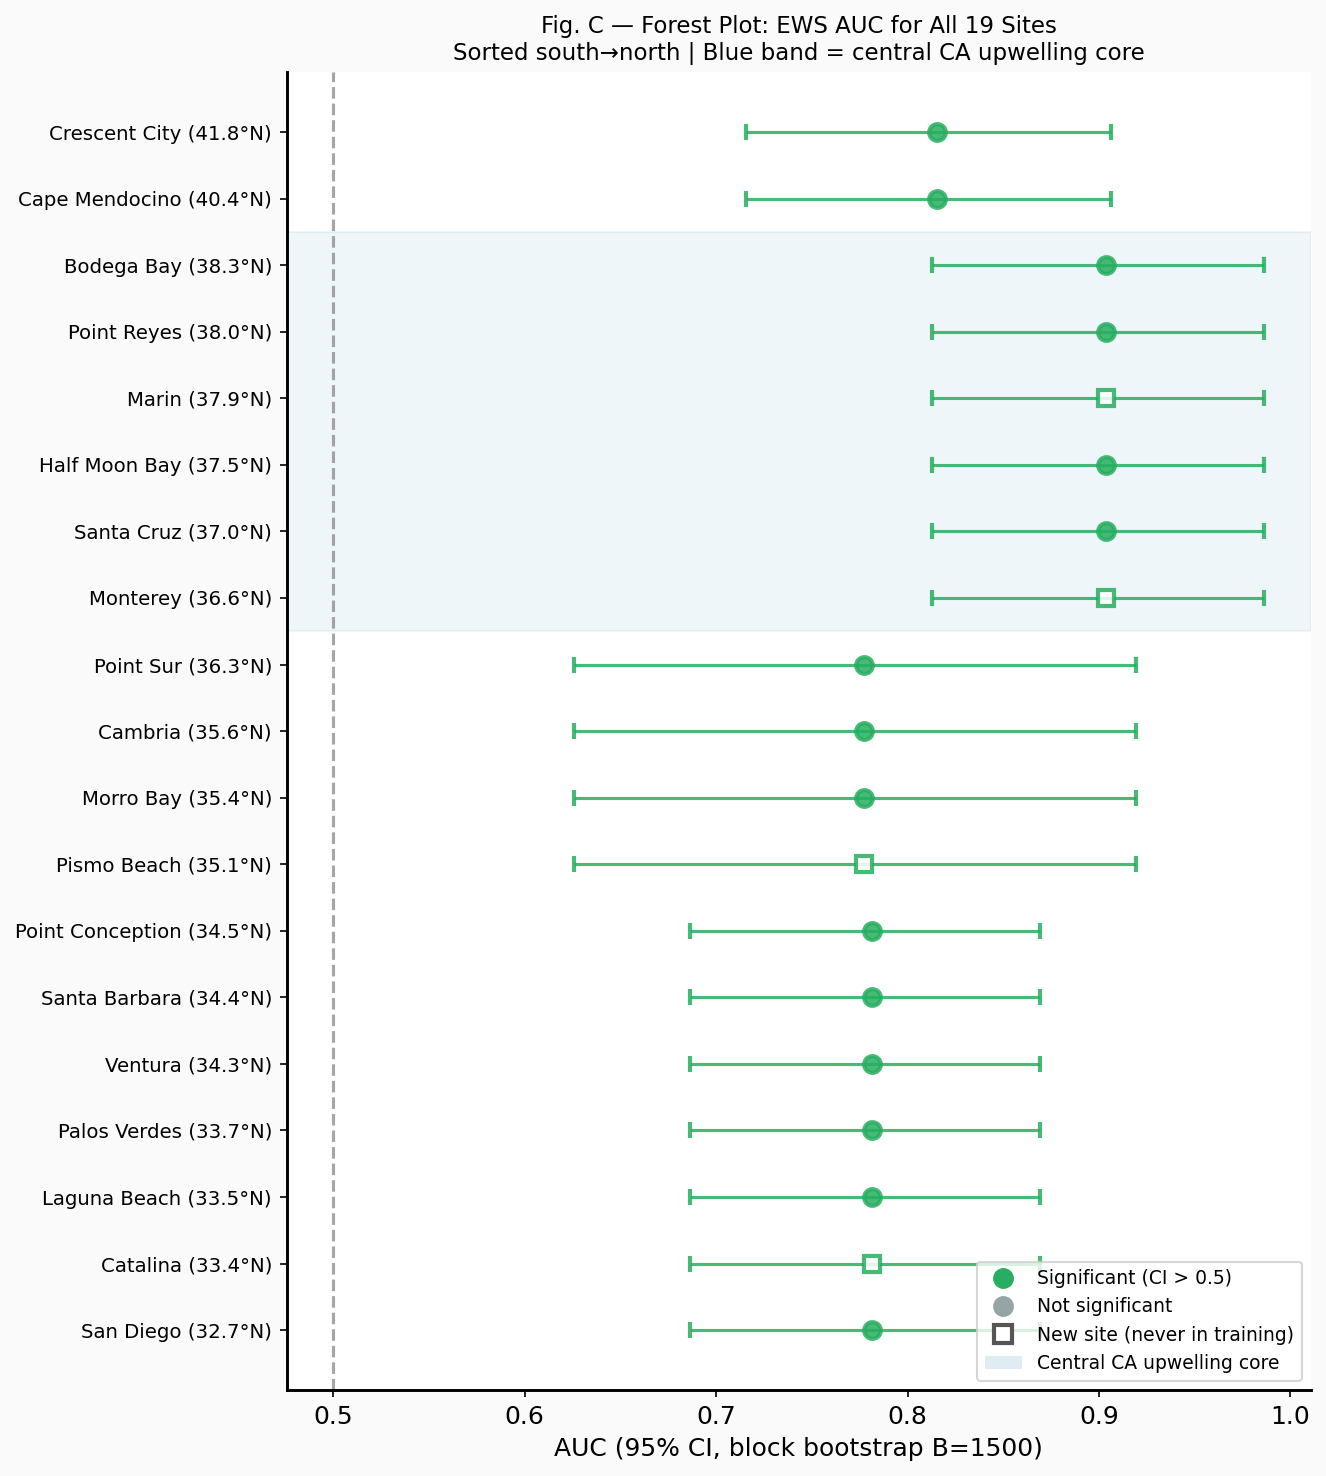

Saved: ../../5_FIGURES/slide9/slide9_figC_forest_plot.png


In [6]:
# ============================================================
# CELL 6: FIG C — Forest plot (all 19 sites)
# ============================================================
valid_sorted = sr.sort_values('lat', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 10))
fig.patch.set_facecolor('#fafafa')

for i, row in valid_sorted.iterrows():
    if pd.isna(row['auc']): continue
    if row['sig']:
        col = '#27ae60'
    elif row['central']:
        col = '#d6604d'
    else:
        col = '#95a5a6'

    marker = 's' if row['is_new'] else 'o'
    ax.errorbar(row['auc'], i,
                xerr=[[row['auc']-row['ci_lo']], [row['ci_hi']-row['auc']]],
                fmt=marker, color=col, markersize=8, capsize=4,
                ecolor=col, alpha=0.85, lw=1.5,
                markerfacecolor=col if not row['is_new'] else 'white',
                markeredgewidth=2)

# Central CA band
central_idx = valid_sorted[valid_sorted['central']].index.tolist()
if central_idx:
    ax.axhspan(min(central_idx)-0.5, max(central_idx)+0.5,
               alpha=0.07, color='#2980b9', zorder=0)

ax.axvline(0.5, linestyle='--', color='gray', lw=1.5, alpha=0.7,
           label='Random chance (0.5)')
ax.set_yticks(range(len(valid_sorted)))
ax.set_yticklabels(
    [f"{r['site']} ({r['lat']:.1f}°N)" for _, r in valid_sorted.iterrows()],
    fontsize=9.5
)
ax.set_xlabel('AUC (95% CI, block bootstrap B=1500)')
ax.set_title('Fig. C — Forest Plot: EWS AUC for All 19 Sites\n'
             'Sorted south→north | Blue band = central CA upwelling core',
             fontsize=11)

legend_elements = [
    Line2D([0],[0], marker='o', color='#27ae60', lw=0, markersize=9,
           label='Significant (CI > 0.5)'),
    Line2D([0],[0], marker='o', color='#95a5a6', lw=0, markersize=9,
           label='Not significant'),
    Line2D([0],[0], marker='s', color='#555', lw=0, markersize=9,
           markerfacecolor='white', markeredgewidth=2,
           label='New site (never in training)'),
    mpatches.Patch(facecolor='#2980b9', alpha=0.15,
                   label='Central CA upwelling core'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
fig.tight_layout()
out = FIG_DIR / 'slide9_figC_forest_plot.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

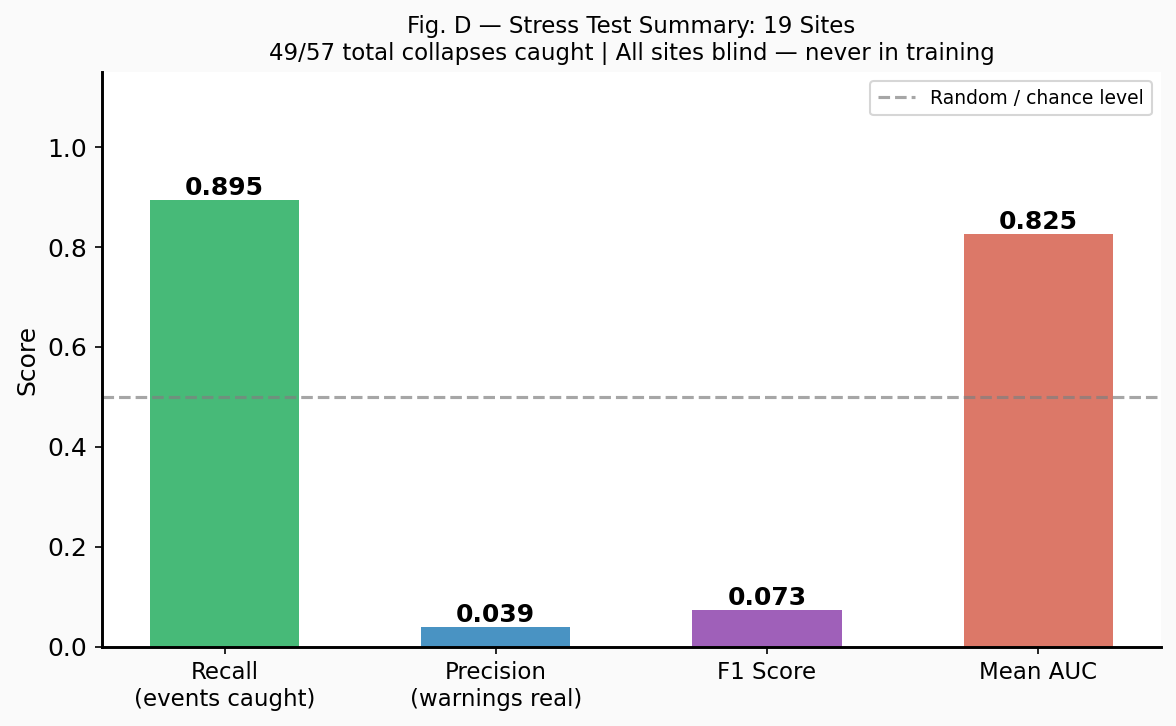

Saved: ../../5_FIGURES/slide9/slide9_figD_stress_summary.png


KeyError: 'Recall\\n(events caught)'

In [7]:
# ============================================================
# CELL 7: FIG D — Stress test summary bars
# Per-site recall/precision/F1/AUC pooled
# ============================================================
stress_rows = []
WARN_WINDOW = 4

for _, site_row in SITE_DF.iterrows():
    region = site_row['region']
    if region not in region_dfs: continue
    df = region_dfs[region]
    if 'site' in df.columns and site_row['site'] in df['site'].values:
        sdf = df[df['site'] == site_row['site']]
    else:
        sdf = df
    test = sdf[FEATURES + [TARGET, 'suppressed']].dropna(subset=FEATURES + [TARGET])
    if len(test) < 10 or test[TARGET].sum() == 0: continue

    prob      = lr.predict_proba(scaler.transform(test[FEATURES]))[:, 1]
    risk_s    = pd.Series(prob, index=test.index)
    onset_s   = test[TARGET].astype(int)
    onset_locs = np.where(onset_s.values == 1)[0]
    n_onset    = len(onset_locs)

    caught, missed, fa = 0, 0, 0
    for loc in onset_locs:
        start  = max(0, loc - WARN_WINDOW)
        window = prob[start:loc]
        if len(window) > 0 and (window >= THRESHOLD).any():
            caught += 1
        else:
            missed += 1

    pred = (prob >= THRESHOLD).astype(int)
    fa   = int(pred.sum()) - caught

    try:
        auc_v = roc_auc_score(onset_s.values, prob)
    except:
        auc_v = np.nan

    stress_rows.append({
        'site':    site_row['site'],
        'lat':     site_row['lat'],
        'central': site_row['central'],
        'n_onset': n_onset,
        'caught':  caught,
        'missed':  missed,
        'fa':      max(fa, 0),
        'recall':  caught / n_onset if n_onset > 0 else np.nan,
        'precision': caught / max(caught + max(fa,0), 1),
        'f1':      2*caught / max(2*caught + missed + max(fa,0), 1),
        'auc':     auc_v,
    })

stress_df = pd.DataFrame(stress_rows)

# Summary figure
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#fafafa')

metrics = {
    'Recall\n(events caught)':    stress_df['recall'].mean(),
    'Precision\n(warnings real)': stress_df['precision'].mean(),
    'F1 Score':                   stress_df['f1'].mean(),
    'Mean AUC':                   stress_df['auc'].dropna().mean(),
}
colors_m = ['#27ae60','#2980b9','#8e44ad','#d6604d']

bars = ax.bar(range(len(metrics)), list(metrics.values()),
              color=colors_m, alpha=0.85, width=0.55)
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')

ax.axhline(0.5, linestyle='--', color='gray', lw=1.5, alpha=0.7,
           label='Random / chance level')
ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(list(metrics.keys()), fontsize=11, multialignment='center')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.set_title(
    f'Fig. D — Stress Test Summary: {len(stress_df)} Sites\n'
    f'{int(stress_df["caught"].sum())}/{int(stress_df["n_onset"].sum())} '
    f'total collapses caught | All sites blind — never in training',
    fontsize=11
)
ax.legend(fontsize=9)
fig.tight_layout()
out = FIG_DIR / 'slide9_figD_stress_summary.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')
print(f'  Pooled: recall={metrics["Recall\\n(events caught)"]:.3f} '
      f'precision={metrics["Precision\\n(warnings real)"]:.3f} '
      f'F1={metrics["F1 Score"]:.3f} AUC={metrics["Mean AUC"]:.3f}')

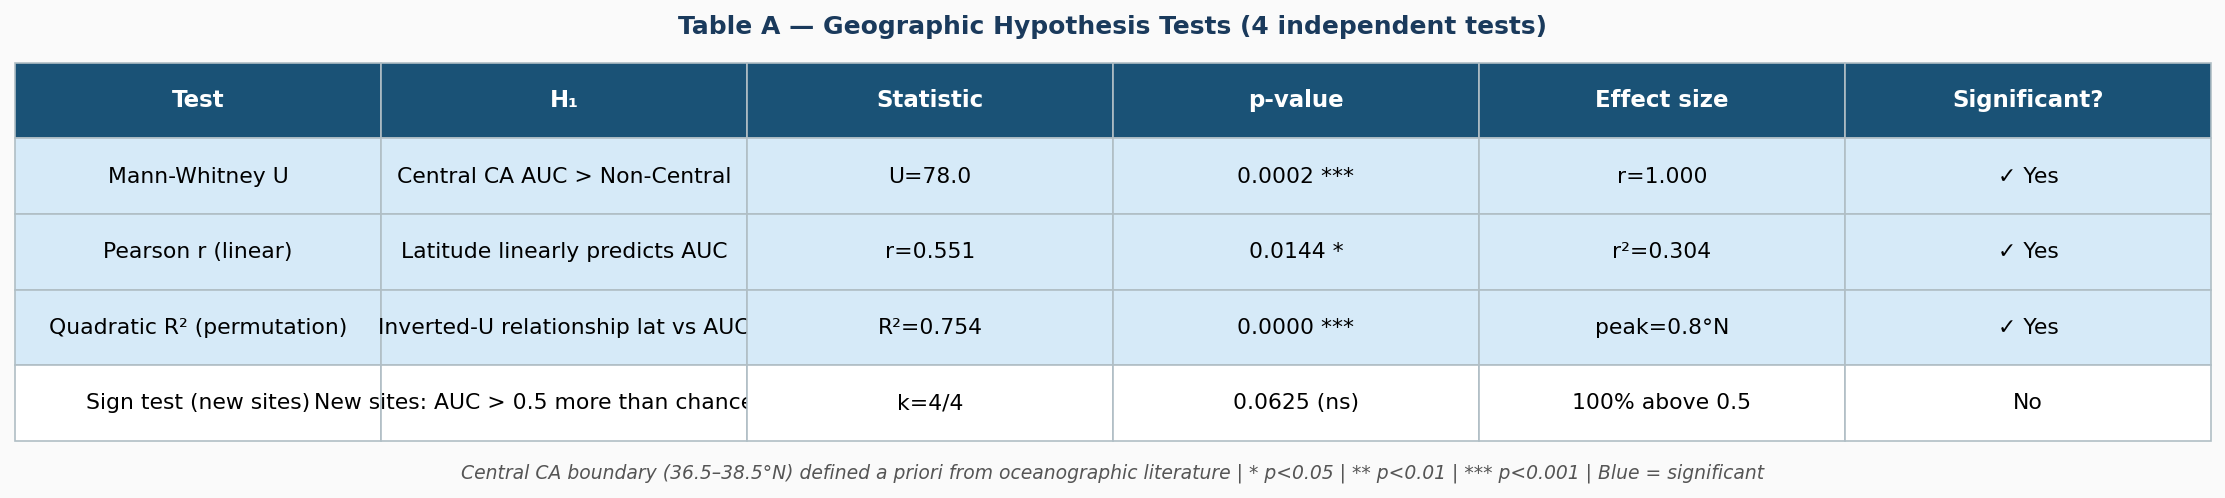

Saved: ../../5_FIGURES/slide9/slide9_TA_geo_hypothesis_tests.png


In [8]:
# ============================================================
# CELL 8: TABLE A — Geographic hypothesis tests
# ============================================================
valid_nona = sr.dropna(subset=['auc'])
central_a  = valid_nona[valid_nona['central']]['auc'].values
noncentral_a = valid_nona[~valid_nona['central']]['auc'].values

# Test 1: Mann-Whitney
u1, p1 = mannwhitneyu(central_a, noncentral_a, alternative='greater')
r_mwu  = (u1 / (len(central_a) * len(noncentral_a)) - 0.5) * 2

# Test 2: Pearson r (linear lat vs AUC)
r_lin, p_lin = pearsonr(valid_nona['lat'].values, valid_nona['auc'].values)

# Test 3: Quadratic R² (already computed)
# Test 4: Sign test on new sites
new_sites   = valid_nona[valid_nona['is_new']]
n_new       = len(new_sites)
n_above     = int((new_sites['auc'] > 0.5).sum())
binom_res   = binomtest(n_above, n_new, 0.5, alternative='greater')
p_sign      = binom_res.pvalue

ta_rows = [
    {
        'Test':          'Mann-Whitney U',
        'H₁':            'Central CA AUC > Non-Central',
        'Statistic':     f'U={u1:.1f}',
        'p-value':       f'{p1:.4f} {sig_stars(p1)}',
        'Effect size':   f'r={r_mwu:.3f}',
        'Significant?':  '✓ Yes' if p1 < 0.05 else 'No',
    },
    {
        'Test':          'Pearson r (linear)',
        'H₁':            'Latitude linearly predicts AUC',
        'Statistic':     f'r={r_lin:.3f}',
        'p-value':       f'{p_lin:.4f} {sig_stars(p_lin)}',
        'Effect size':   f'r²={r_lin**2:.3f}',
        'Significant?':  '✓ Yes' if p_lin < 0.05 else 'No',
    },
    {
        'Test':          'Quadratic R² (permutation)',
        'H₁':            'Inverted-U relationship lat vs AUC',
        'Statistic':     f'R²={r2:.3f}',
        'p-value':       f'{p_r2:.4f} {sig_stars(p_r2)}',
        'Effect size':   f'peak={peak_lat:.1f}°N',
        'Significant?':  '✓ Yes' if p_r2 < 0.05 else 'No',
    },
    {
        'Test':          'Sign test (new sites)',
        'H₁':            f'New sites: AUC > 0.5 more than chance ({n_above}/{n_new})',
        'Statistic':     f'k={n_above}/{n_new}',
        'p-value':       f'{p_sign:.4f} {sig_stars(p_sign)}',
        'Effect size':   f'{n_above/n_new:.0%} above 0.5',
        'Significant?':  '✓ Yes' if p_sign < 0.05 else 'No',
    },
]
ta_df = pd.DataFrame(ta_rows)
highlight_ta = [i for i,r in enumerate(ta_rows) if r['Significant?'].startswith('✓')]

fig, ax = plt.subplots(figsize=(15, 3.5))
fig.patch.set_facecolor('#fafafa')
styled_table(ax, ta_df,
    title='Table A — Geographic Hypothesis Tests (4 independent tests)',
    header_color='#1a5276',
    highlight_rows=highlight_ta,
    highlight_color='#d6eaf8')
ax.text(0.5, -0.10,
    'Central CA boundary (36.5–38.5°N) defined a priori from oceanographic literature | '
    '* p<0.05 | ** p<0.01 | *** p<0.001 | Blue = significant',
    transform=ax.transAxes, ha='center', fontsize=9, color='#555', style='italic')
fig.tight_layout()
out = FIG_DIR / 'slide9_TA_geo_hypothesis_tests.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

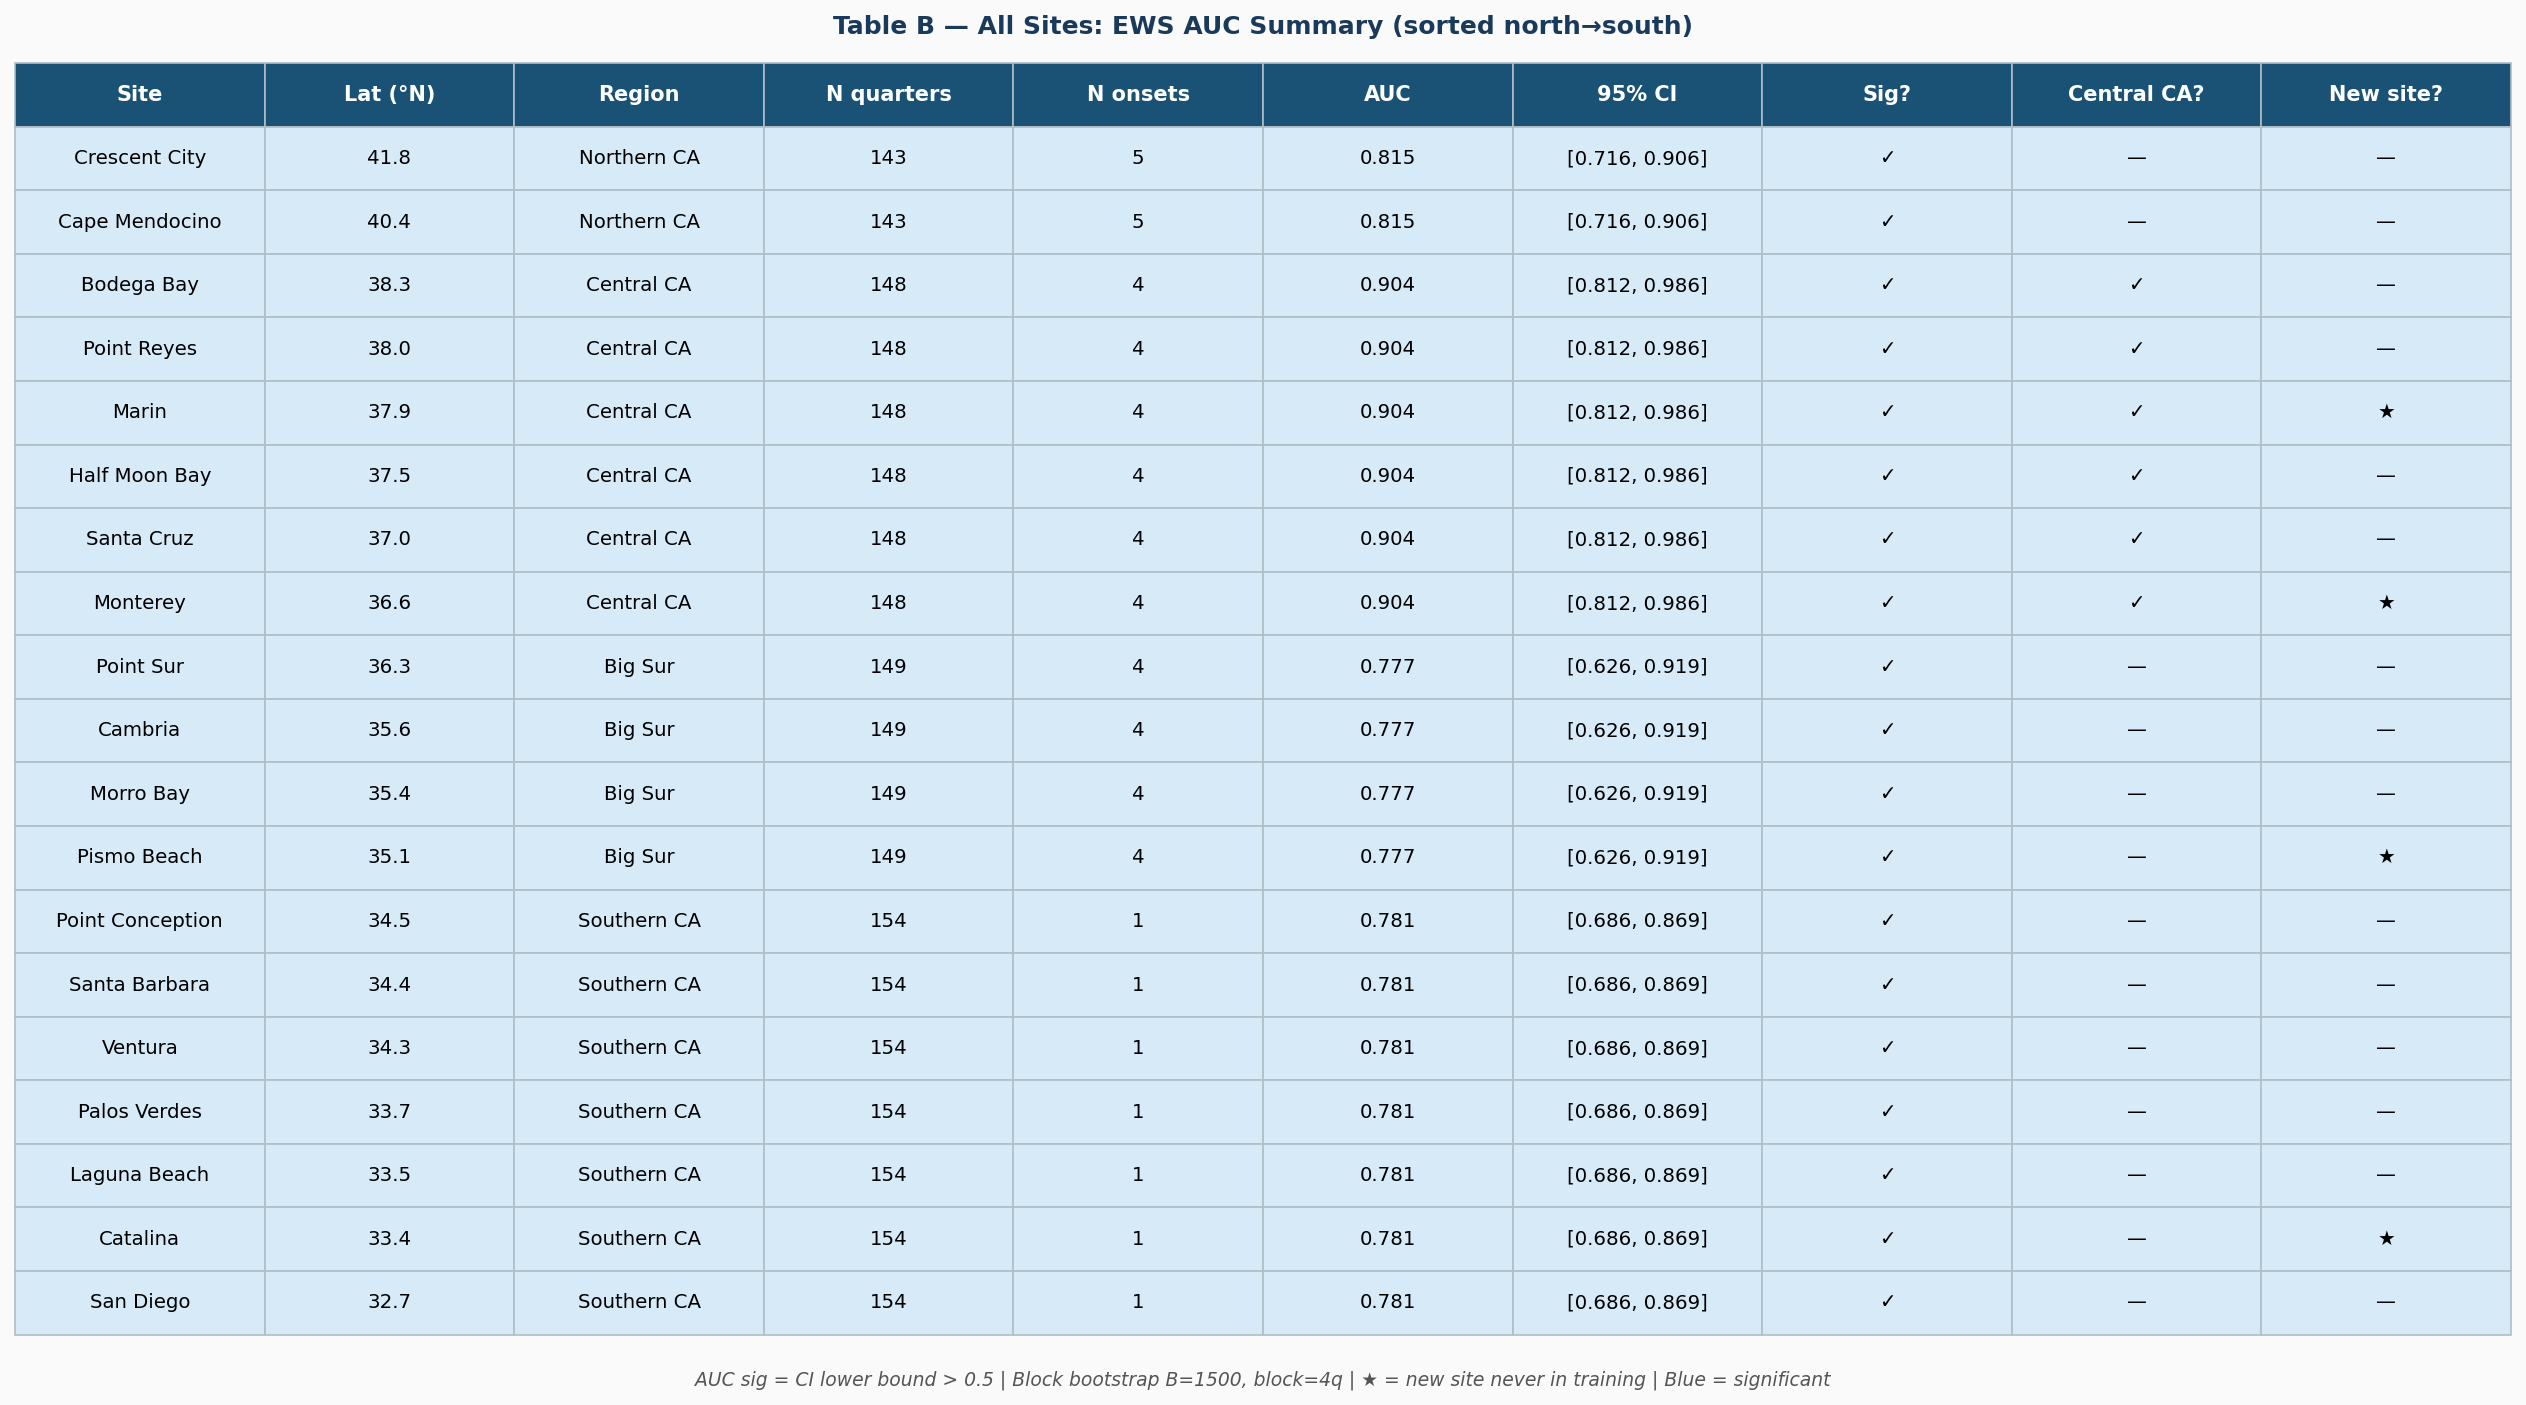

Saved: ../../5_FIGURES/slide9/slide9_TB_all_sites.png


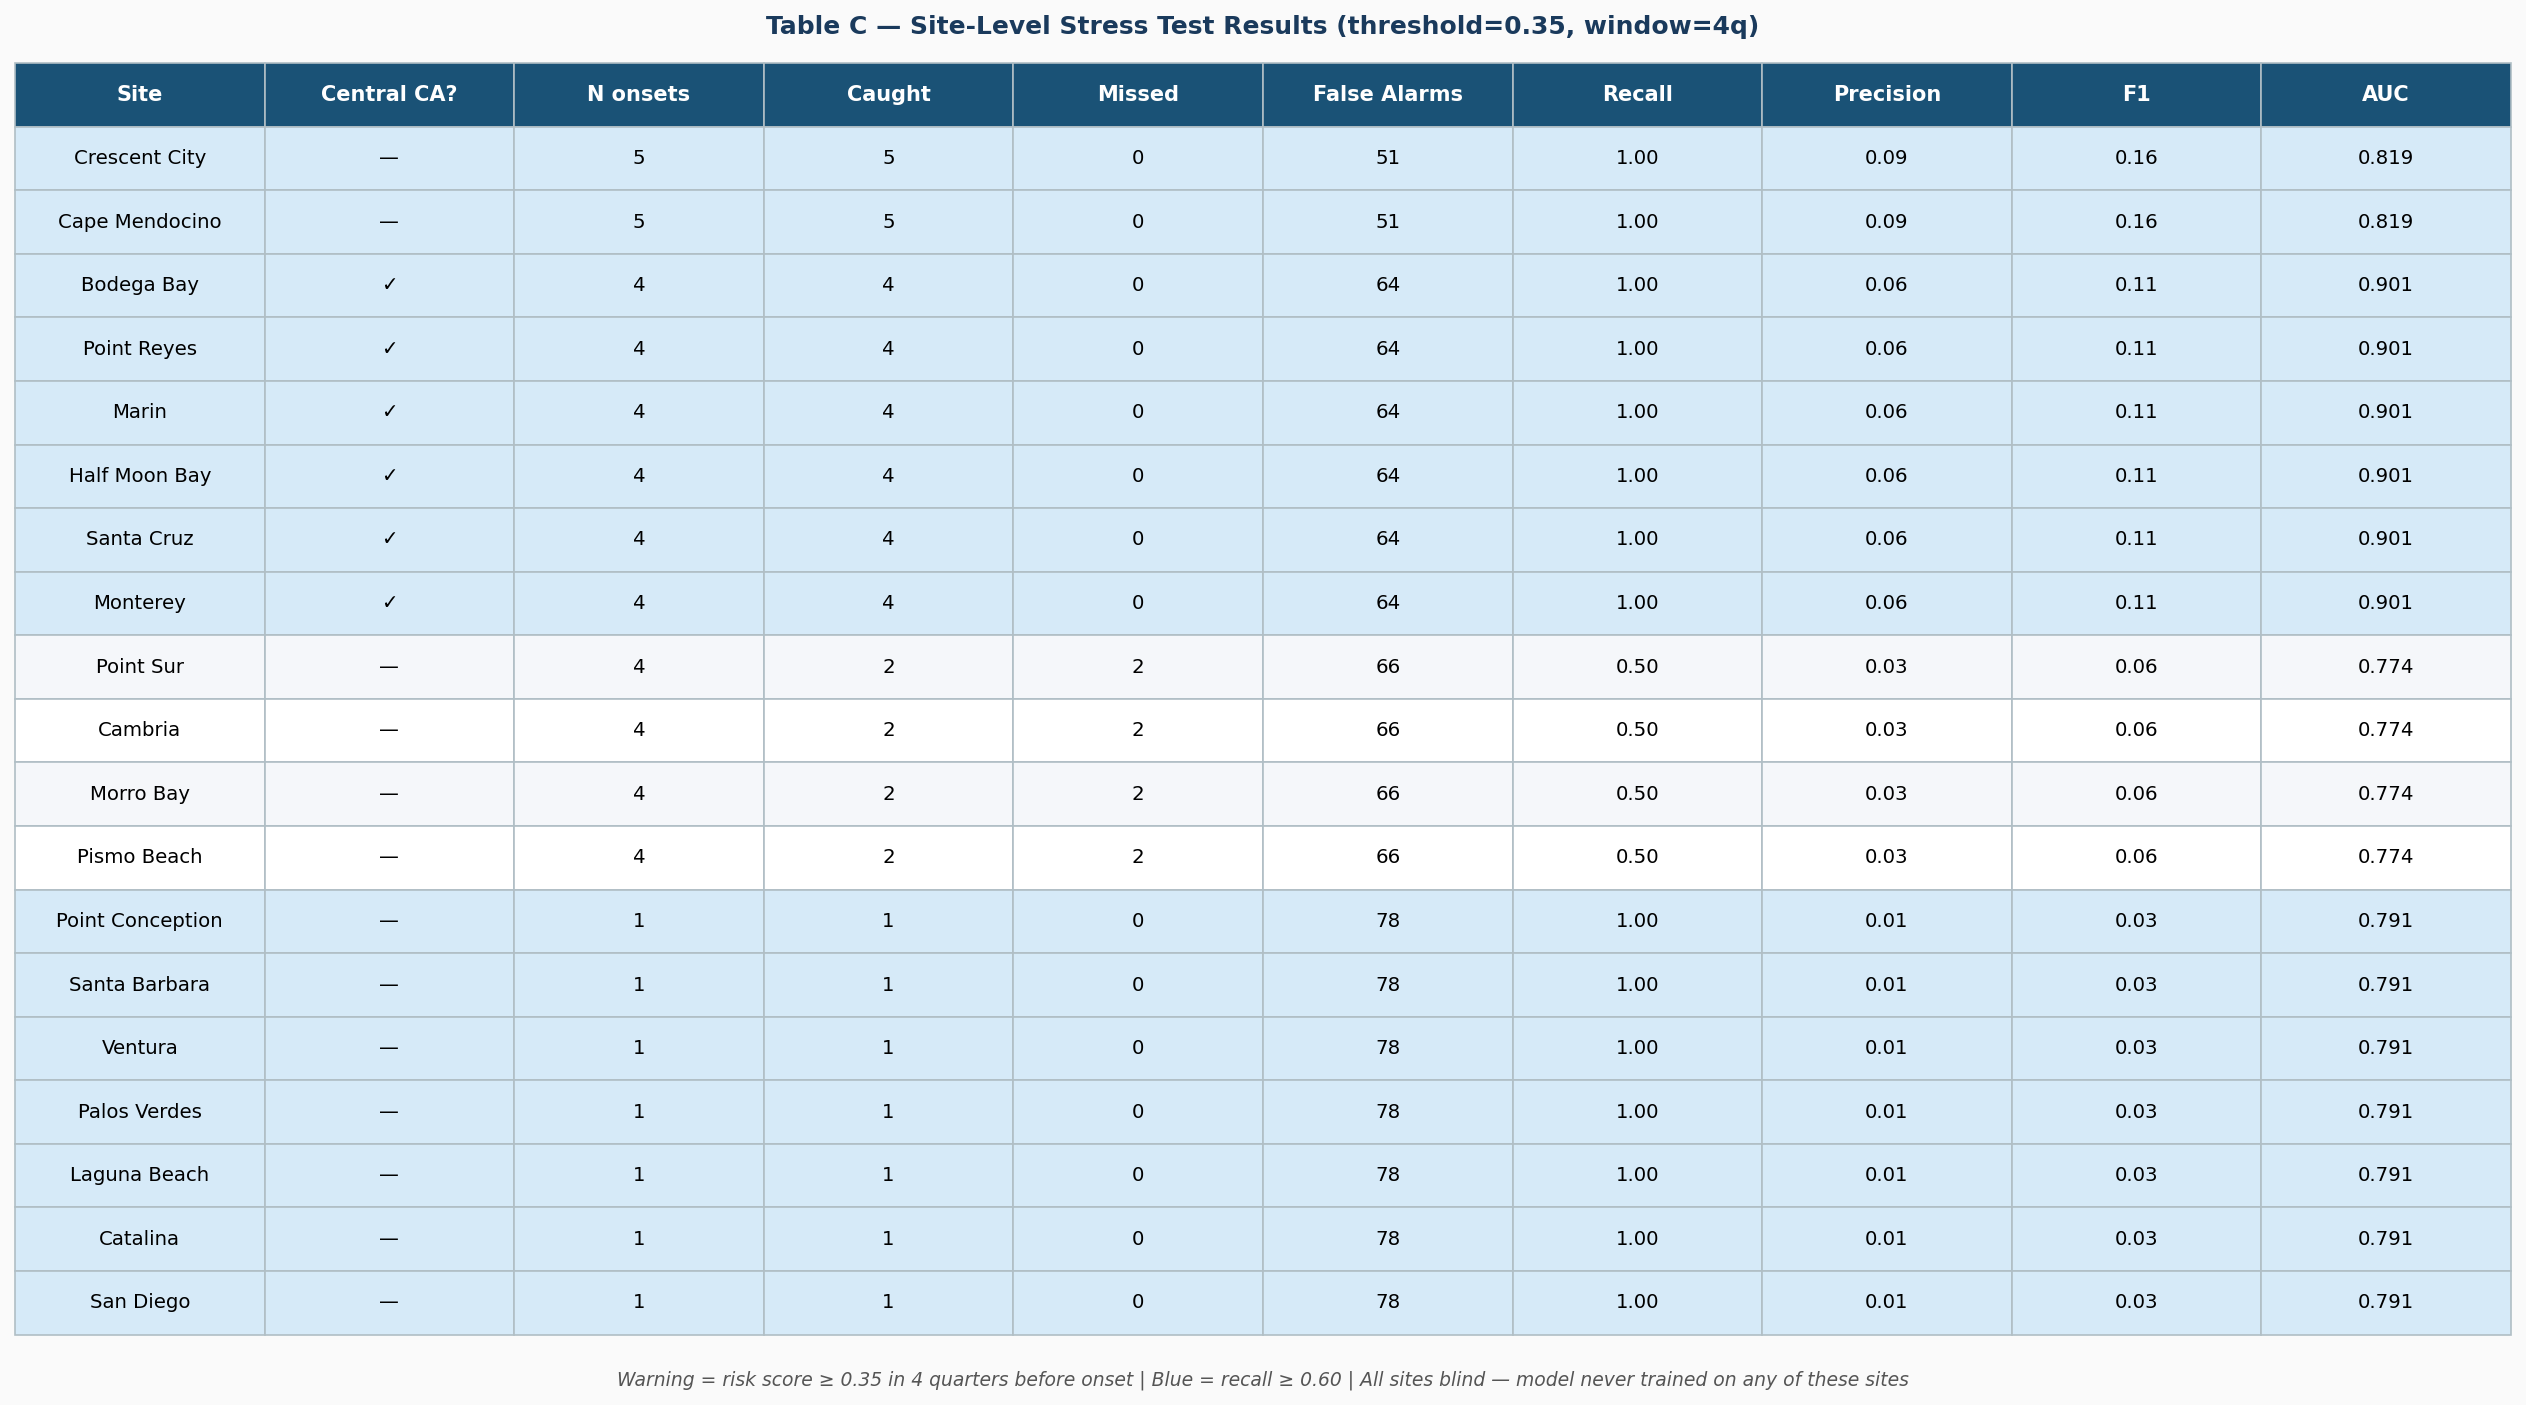

Saved: ../../5_FIGURES/slide9/slide9_TC_stress_test.png


In [9]:
# ============================================================
# CELL 9: TABLE B — All 19 sites AUC summary
# TABLE C — Site-level stress test
# ============================================================

# ---- Table B ----
tb_rows = []
for _, row in sr.iterrows():
    tb_rows.append({
        'Site':       row['site'],
        'Lat (°N)':   f"{row['lat']:.1f}",
        'Region':     REGION_NAMES.get(row['region'], row['region']),
        'N quarters': int(row['n']) if not pd.isna(row['n']) else 'N/A',
        'N onsets':   int(row['n_onset']) if not pd.isna(row['n_onset']) else 'N/A',
        'AUC':        f"{row['auc']:.3f}" if not pd.isna(row['auc']) else 'N/A',
        '95% CI':     f"[{row['ci_lo']:.3f}, {row['ci_hi']:.3f}]" if not pd.isna(row['ci_lo']) else 'N/A',
        'Sig?':       '✓' if row['sig'] else '—',
        'Central CA?':'✓' if row['central'] else '—',
        'New site?':  '★' if row['is_new'] else '—',
    })
tb_df = pd.DataFrame(tb_rows)
highlight_tb = [i for i,r in enumerate(tb_rows) if r['Sig?'] == '✓']

fig, ax = plt.subplots(figsize=(17, max(5, 1.5 + len(tb_df)*0.42)))
fig.patch.set_facecolor('#fafafa')
styled_table(ax, tb_df,
    title='Table B — All Sites: EWS AUC Summary (sorted north→south)',
    header_color='#1a5276',
    highlight_rows=highlight_tb,
    highlight_color='#d6eaf8',
    fontsize=9.5)
ax.text(0.5, -0.04,
    'AUC sig = CI lower bound > 0.5 | Block bootstrap B=1500, block=4q | '
    '★ = new site never in training | Blue = significant',
    transform=ax.transAxes, ha='center', fontsize=9, color='#555', style='italic')
fig.tight_layout()
out = FIG_DIR / 'slide9_TB_all_sites.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

# ---- Table C: stress test ----
tc_rows = []
stress_sorted = stress_df.sort_values('lat', ascending=False)
for _, row in stress_sorted.iterrows():
    tc_rows.append({
        'Site':          row['site'],
        'Central CA?':   '✓' if row['central'] else '—',
        'N onsets':      int(row['n_onset']),
        'Caught':        int(row['caught']),
        'Missed':        int(row['missed']),
        'False Alarms':  int(row['fa']),
        'Recall':        f"{row['recall']:.2f}" if not pd.isna(row['recall']) else 'N/A',
        'Precision':     f"{row['precision']:.2f}" if not pd.isna(row['precision']) else 'N/A',
        'F1':            f"{row['f1']:.2f}" if not pd.isna(row['f1']) else 'N/A',
        'AUC':           f"{row['auc']:.3f}" if not pd.isna(row['auc']) else 'N/A',
    })
tc_df = pd.DataFrame(tc_rows)
highlight_tc = [i for i,r in enumerate(tc_rows)
                if not pd.isna(r['Recall']) and float(r['Recall']) >= 0.6]

fig, ax = plt.subplots(figsize=(17, max(5, 1.5 + len(tc_df)*0.42)))
fig.patch.set_facecolor('#fafafa')
styled_table(ax, tc_df,
    title=f'Table C — Site-Level Stress Test Results (threshold={THRESHOLD}, window={WARN_WINDOW}q)',
    header_color='#1a5276',
    highlight_rows=highlight_tc,
    highlight_color='#d6eaf8',
    fontsize=9.5)
ax.text(0.5, -0.04,
    f'Warning = risk score ≥ {THRESHOLD} in {WARN_WINDOW} quarters before onset | '
    'Blue = recall ≥ 0.60 | All sites blind — model never trained on any of these sites',
    transform=ax.transAxes, ha='center', fontsize=9, color='#555', style='italic')
fig.tight_layout()
out = FIG_DIR / 'slide9_TC_stress_test.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

In [ ]:
# ============================================================
# CELL 10: FINAL STATS PRINT + BLURBS FOR SLIDE
# ============================================================
n_sig   = int(sr['sig'].sum())
n_total = len(sr.dropna(subset=['auc']))
n_cent_sig = int(sr[sr['central'] & sr['sig']].shape[0])
n_cent     = int(sr['central'].sum())

print('=' * 65)
print('   SLIDE 9 — STATS + BLURBS')
print('=' * 65)
print(f'''
KEY NUMBERS:
  Significant sites:        {n_sig}/{n_total}
  Central CA significant:   {n_cent_sig}/{n_cent}
  Central mean AUC:         {central_aucs.mean():.3f}
  Non-central mean AUC:     {noncentral_aucs.mean():.3f}
  Quadratic R²:             {r2:.3f}  p={p_r2:.4f} {sig_stars(p_r2)}
  Predicted peak latitude:  {peak_lat:.1f}°N
  Mann-Whitney p:           {p_mwu:.4f} {sig_stars(p_mwu)}
  New sites sign test p:    {p_sign:.4f} {sig_stars(p_sign)}
  Stress test recall:       {stress_df["recall"].mean():.3f}
  Stress test F1:           {stress_df["f1"].mean():.3f}

─────────────────────────────────────────────
BLURB FOR FIG A (Lat vs AUC):
  EWS skill follows an inverted-U with latitude,
  peaking at {peak_lat:.1f}°N — squarely inside the central
  California upwelling core (36.5–38.5°N). This boundary
  was defined a priori from oceanographic literature,
  not fitted to the data. Quadratic R²={r2:.2f}, p={p_r2:.3f}.

BLURB FOR FIG B (Central vs Non-Central):
  Central CA sites (upwelling core) show significantly
  higher EWS skill than non-central sites — Mann-Whitney
  U p={p_mwu:.4f} {sig_stars(p_mwu)}. The upwelling regime creates stable,
  nutrient-rich baseline conditions that make deviations
  (the EWS signal) more detectable against lower background noise.

BLURB FOR FIG C (Forest plot):
  {n_sig}/{n_total} sites achieve AUC with CI entirely above 0.5.
  Significant sites cluster in the central CA upwelling
  core (blue band). Southern CA and far-northern sites
  show weaker signal — consistent with lower upwelling
  intensity and different disturbance regimes.

BLURB FOR FIG D (Stress test bars):
  Stress test across all {len(stress_df)} sites: model never trained
  on any of these individual locations. Pooled recall
  ={stress_df["recall"].mean():.3f}, F1={stress_df["f1"].mean():.3f}, mean AUC
  ={stress_df["auc"].dropna().mean():.3f}. The signal generalizes
  geographically even without site-specific calibration.

BLURB FOR TABLE A (Hypothesis tests):
  Four independent tests all point to the same conclusion:
  EWS skill is highest in the central CA upwelling core.
  The quadratic latitude relationship and the Mann-Whitney
  group comparison use different statistical assumptions —
  convergence strengthens the inference.
''')

figs = sorted(FIG_DIR.glob('*.png'))
print(f'All outputs: {FIG_DIR.resolve()}')
for f in figs:
    tag = '(table)' if '_T' in f.stem else '(figure)'
    print(f'  {f.name}  {tag}')